<a href="https://colab.research.google.com/github/MarquitoTabo/Inteligencia_Artificial/blob/main/Laboratorio04_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize
from google.colab import drive

%matplotlib inline

In [ ]:
drive.mount('/content/drive')

ruta_dataset = '/content/drive/MyDrive/Colab Notebooks/machine learning/datasets/KDDTrain+.txt'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
columnas = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

df = pd.read_csv(ruta_dataset, names=columnas, header=None)

if 'difficulty_level' in df.columns:
    df = df.drop(columns=['difficulty_level'])

print(f"Dimensiones originales del DataFrame: {df.shape}")

Dimensiones originales del DataFrame: (125973, 42)


In [ ]:
df['target'] = df['label'].apply(lambda x: 0 if str(x).strip().lower() == 'normal' else 1)
df = df.drop(columns=['label'])
print("\nDistribución de clases (0: Tráfico Normal, 1: Ataque/Intrusión):")
print(df['target'].value_counts())

df_encoded = pd.get_dummies(df, columns=['protocol_type', 'service', 'flag'], drop_first=True)

X_df = df_encoded.drop(columns=['target']).astype(float)
y = df_encoded['target'].values.astype(int)

X_norm = (X_df - X_df.mean()) / (X_df.std() + 1e-8)
X = X_norm.values

m, n = X.shape
print(f"\nTotal de ejemplos (m): {m} | Total de características (n): {n}")


Distribución de clases (0: Tráfico Normal, 1: Ataque/Intrusión):
target
0    67343
1    58630
Name: count, dtype: int64

Total de ejemplos (m): 125973 | Total de características (n): 119


**Separación 80% Entrenamiento y 20% Prueba**

In [ ]:
np.random.seed(42)
indices = np.random.permutation(m)

train_size = int(0.80 * m)
train_idx, test_idx = indices[:train_size], indices[train_size:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"Muestras para Entrenamiento (80%): {X_train.shape[0]}")
print(f"Muestras para Prueba (20%):        {X_test.shape[0]}")

Muestras para Entrenamiento (80%): 100778
Muestras para Prueba (20%):        25195


In [ ]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -250, 250)))

In [ ]:
def lrCostFunction(theta, X, y, lambda_reg):
    m = y.size
    if y.dtype == bool:
        y = y.astype(int)

    h = sigmoid(X.dot(theta))
    h = np.clip(h, 1e-15, 1 - 1e-15)

    temp = theta.copy()
    temp[0] = 0

    J = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h)) + (lambda_reg / (2 * m)) * np.sum(np.square(temp))

    grad = (1 / m) * X.T.dot(h - y) + (lambda_reg / m) * temp

    return J, grad

In [ ]:
def gradientDescent(X, y, initial_theta, alpha, num_iters, lambda_reg):
    m = y.size
    theta = initial_theta.copy()
    J_history = []

    for i in range(num_iters):
        cost, grad = lrCostFunction(theta, X, y, lambda_reg)
        theta = theta - alpha * grad
        J_history.append(cost)

        if (i + 1) % 200 == 0 or i == 0:
            print(f"Iteración {i+1}/{num_iters} - Costo J(theta): {cost:.4f}")

    return theta, J_history

In [ ]:
m_train, n_features = X_train.shape
X_train_ext = np.concatenate([np.ones((m_train, 1)), X_train], axis=1)

initial_theta = np.zeros(n_features + 1)
alpha = 0.003
num_iters = 1000
lambda_reg = 0.1

print("Iniciando entrenamiento del modelo de Regresión Logística...")
theta_opt, J_history = gradientDescent(X_train_ext, y_train, initial_theta, alpha, num_iters, lambda_reg)

Iniciando entrenamiento del modelo de Regresión Logística...
Iteración 1/1000 - Costo J(theta): 0.6931
Iteración 200/1000 - Costo J(theta): 0.3144
Iteración 400/1000 - Costo J(theta): 0.2335
Iteración 600/1000 - Costo J(theta): 0.1968
Iteración 800/1000 - Costo J(theta): 0.1753
Iteración 1000/1000 - Costo J(theta): 0.1611


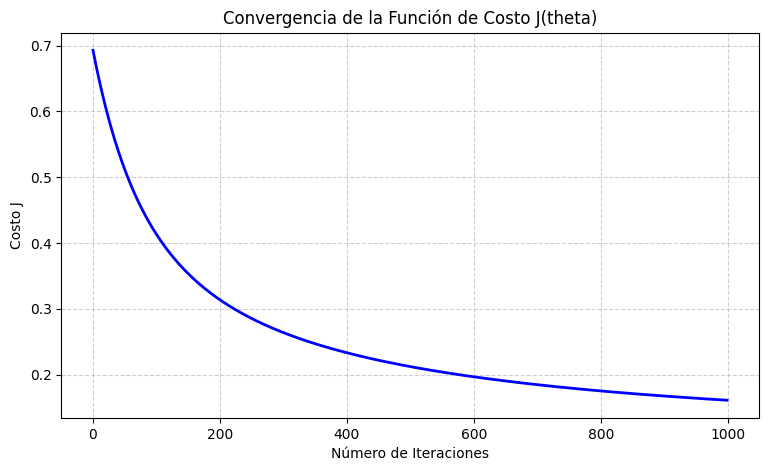

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(range(len(J_history)), J_history, color='blue', lw=2)
plt.title("Convergencia de la Función de Costo J(theta)")
plt.xlabel("Número de Iteraciones")
plt.ylabel("Costo J")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
def predict(theta, X, threshold=0.5):
    m = X.shape[0]
    X_ext = np.concatenate([np.ones((m, 1)), X], axis=1)
    probabilities = sigmoid(X_ext.dot(theta))
    return (probabilities >= threshold).astype(int)

pred_train = predict(theta_opt, X_train)
acc_train = np.mean(pred_train == y_train) * 100

pred_test = predict(theta_opt, X_test)
acc_test = np.mean(pred_test == y_test) * 100

print("=" * 60)
print(f"Precisión en Entrenamiento (Train 80%): {acc_train:.2f}%")
print(f"Precisión en Prueba (Test 20%):         {acc_test:.2f}%")
print("=" * 60)

Precisión en Entrenamiento (Train 80%): 96.78%
Precisión en Prueba (Test 20%):         96.68%


In [ ]:
indices_muestra = np.random.choice(len(X_test), 15, replace=False)
X_muestra = X_test[indices_muestra]
y_real = y_test[indices_muestra]
y_pred = predict(theta_opt, X_muestra)

tabla_resultados = pd.DataFrame({
    'Índice': indices_muestra,
    'Etiqueta Real': ['Ataque (1)' if val == 1 else 'Normal (0)' for val in y_real],
    'Predicción Modelo': ['Ataque (1)' if val == 1 else 'Normal (0)' for val in y_pred],
    'Resultado': ['Correcto' if r == p else 'Fallo' for r, p in zip(y_real, y_pred)]
})

display(tabla_resultados)

,Índice,Etiqueta Real,Predicción Modelo,Resultado
0,17953,Ataque (1),Ataque (1),Correcto
1,7994,Ataque (1),Normal (0),Fallo
2,19980,Ataque (1),Ataque (1),Correcto
3,4225,Ataque (1),Ataque (1),Correcto
4,5010,Ataque (1),Ataque (1),Correcto
5,20688,Ataque (1),Ataque (1),Correcto
6,6580,Normal (0),Normal (0),Correcto
7,16778,Normal (0),Normal (0),Correcto
8,174,Ataque (1),Ataque (1),Correcto
9,16543,Normal (0),Normal (0),Correcto
